In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

from src.data_loader import load_week1_outputs
from src.allocation_baseline import(
    get_symbols_at_latest_period,
    compute_equal_weights,
    compute_market_caps
)

✓ API key đã được lưu thành công! (API key saved successfully!)
Bạn đang sử dụng Phiên bản cộng đồng (60 requests/phút)
(You are using Community version - 60 requests/minute)

Để tham gia gói thành viên tài trợ (To join sponsor membership):
  Truy cập: https://vnstocks.com/insiders-program
✓ API key đã được lưu thành công! (✓ API key saved successfully! vnst***6a67
✓ Bạn đang sử dụng gói Cộng đồng (✓ You are using Community Edition - 60 requests/min)


In [14]:
# Reload all output from Week 1
data = load_week1_outputs()
prices_pivot = data['prices_pivot']
log_returns = data['log_returns']
pit_membership = data['pit_membership']
vn30_index = data['vn30_index']

In [4]:
# Take symbols and calculate market cap
symbols_at_period, latest_period = get_symbols_at_latest_period(pit_membership)
market_caps = compute_market_caps(symbols_at_period, prices_pivot)

In [5]:
from pypfopt import black_litterman, plotting
from pypfopt.black_litterman import BlackLittermanModel
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt.risk_models import CovarianceShrinkage
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
# Reload price subset and calculate shrinkage covariance matrix
prices_subset = prices_pivot[symbols_at_period].dropna(how='any')
print(prices_subset)

print(f"Shape after dropna: {prices_subset.shape}")
print(f"Date range: {prices_subset.index.min()} → {prices_subset.index.max()}")

                       LPB     FPT    TPB    MBB    VIC    VPB    ACB    BSR  \
time                                                                           
2025-05-13 07:00:00  30.59  100.62  12.96  18.38   39.8  16.93  17.73  11.24   
2025-05-14 07:00:00  31.42  106.34  13.15  18.38   39.9  18.08  17.87  11.24   
2025-05-15 07:00:00  32.61  105.25  13.11  18.79   39.9  18.23  18.41  11.15   
2025-05-16 07:00:00  32.13  101.88  12.96  18.49   40.0  17.74  18.34  10.99   
2025-05-19 07:00:00  30.90   99.52  12.82  18.45   42.8  17.88  18.30  10.81   
...                    ...     ...    ...    ...    ...    ...    ...    ...   
2026-06-25 07:00:00  56.00   71.00  16.00  24.70  225.0  26.70  22.40  24.60   
2026-06-26 07:00:00  53.00   70.80  16.10  24.75  228.0  26.75  22.60  24.25   
2026-06-29 07:00:00  54.70   70.40  16.35  25.10  217.2  27.05  22.90  24.40   
2026-06-30 07:00:00  53.50   70.20  16.60  25.20  220.0  27.00  22.65  24.15   
2026-07-01 07:00:00  53.10   72.90  16.7

In [7]:
S = CovarianceShrinkage(prices_subset).ledoit_wolf() # use shrinkage istead of rough `sample_cov`
print(S)

          LPB       FPT       TPB       MBB       VIC       VPB       ACB  \
LPB  0.117679  0.018512  0.036564  0.030520  0.008562  0.050253  0.024863   
FPT  0.018512  0.098785  0.030684  0.024673  0.018674  0.038038  0.030355   
TPB  0.036564  0.030684  0.111205  0.056874  0.020582  0.090117  0.053307   
MBB  0.030520  0.024673  0.056874  0.087004  0.012106  0.065123  0.048029   
VIC  0.008562  0.018674  0.020582  0.012106  0.271719  0.028810  0.011488   
VPB  0.050253  0.038038  0.090117  0.065123  0.028810  0.153895  0.060985   
ACB  0.024863  0.030355  0.053307  0.048029  0.011488  0.060985  0.071486   
BSR  0.026765  0.001075  0.038177  0.025362 -0.012227  0.057543  0.019190   
VHM  0.017250  0.024278  0.034979  0.028316  0.190810  0.046422  0.025833   
BID  0.029585  0.036770  0.050297  0.041198  0.005207  0.054677  0.032396   
GAS  0.006182  0.023835  0.014428  0.009691 -0.005620  0.012238  0.005163   
STB  0.030515  0.021909  0.051220  0.042348  0.010454  0.056967  0.038503   

**Market-implied prior return**

Instead of guessing `expected_returns` for each ticker, Black-Litterman think backward and consider, "if the market is valuing 30 VN30 stocks according to their current market-cap weights, what should the expected return for each stock be to be reasonable (equilibrium)?" This is called reverse optimization.

In [15]:
delta = black_litterman.market_implied_risk_aversion(vn30_index, risk_free_rate=0.035)

market_prior = black_litterman.market_implied_prior_returns(market_caps, delta, S)
print(market_prior.sort_values(ascending=False))

VIC    0.240094
VHM    0.228379
VRE    0.181447
VPB    0.115933
TCB    0.109663
VPL    0.109469
MWG    0.102742
SSI    0.102717
HDB    0.099495
TPB    0.092673
CTG    0.086595
VJC    0.083128
MBB    0.077880
BID    0.077264
VIB    0.073737
MSN    0.073720
SHB    0.072548
GVR    0.070881
STB    0.070810
ACB    0.066515
VCB    0.065239
FPT    0.063783
BSR    0.060478
HPG    0.057447
SSB    0.055106
LPB    0.054222
PLX    0.047153
SAB    0.046019
GAS    0.044105
VNM    0.042772
dtype: float64


`market_prior` is $\pi$ in the Black-Litterman's formula, the anchor for everything that follows, instead of starting from a fabricated number.

**Views**

There are 2 kinds of view:
- Absolute view: "I believe FPT will achieve a return of 20% per year."
- Relative view: "I believe VNM will outperform HPG by 3% per year."

Momentum-based view suggestions (with readily available data, easy to justify):

In [16]:
# Example: calculate 12-months momentum as fundamental for view
lookback = 252 # ~1 trading year
min_required = lookback + 63

eligible_tickers = [
    sym for sym in symbols_at_period
    if prices_pivot[sym].dropna().shape[0] >= min_required
]
excluded = set(symbols_at_period) - set(eligible_tickers)
print(f"Eligible for momentum-based views: {len(eligible_tickers)} / {len(symbols_at_period)}")
print(f"Excluded (insufficient history): {sorted(excluded)}")

momentum = prices_pivot[eligible_tickers].pct_change(lookback).iloc[-1]
top_momentum = momentum.sort_values(ascending=False).head(5)
bottom_momentum = momentum.sort_values(ascending=True).head(5)
print("Top momentum:", top_momentum)
print("Bottom momentum:", bottom_momentum)

Eligible for momentum-based views: 29 / 30
Excluded (insufficient history): ['VPL']
Top momentum: VIC    3.570526
BSR    1.309437
VJC    1.079104
VHM    1.031976
LPB    0.767055
Name: 2026-07-01 07:00:00, dtype: float64
Bottom momentum: FPT   -0.266304
MSN    0.006944
PLX    0.010796
TCB    0.055709
VNM    0.056459
Name: 2026-07-01 07:00:00, dtype: float64


The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.


In [17]:
# Dampening: scale the model to prevent it from becoming illogical
scaled_views = momentum / 10 # divided my 10

viewdict = scaled_views[top_momentum.index].to_dict() # convert into dictionary according to the Black-Litterman standard

print("View:", viewdict)

View: {'VIC': 0.3570526315789474, 'BSR': 0.1309437386569873, 'VJC': 0.10791044776119403, 'VHM': 0.10319759497130358, 'LPB': 0.07670549084858569}


**Omega - view reliability**

Omega ($\Omega$) is the "uncertainty matrix". Because Omega's nature is to measure deviation, its rules go against common intution:

- With BIG Omega: because the margin of error is so large, the view is vague and unreliable
- With SMALL Omega: the margin of error is tiny, view is reliable

In [18]:
bl = BlackLittermanModel(S, pi=market_prior, absolute_views=viewdict)
print(bl.omega)

[[0.01358597 0.         0.         0.         0.        ]
 [0.         0.01372293 0.         0.         0.        ]
 [0.         0.         0.00896397 0.         0.        ]
 [0.         0.         0.         0.01408607 0.        ]
 [0.         0.         0.         0.         0.00588394]]


- With the number `0.013...` (big), the model realises that in the past, this stock had many fluctuation, therefore, it indicates a high margin of error for your forecast on this stock. Hence, the view is less reliable.
- With the number `0.005...` (small), the model found this stock had a steady growth in the past, the prediction has a high posibillity, low margin of error. Therefore, the view is more certain.

**Idzorek's method**

This method allows people to communicate with the model through human's being language: confidence percentage

**Validating view confidence - statistical hit-rate check**

Instead of setting confidence proportional to raw momentum magnitude (which conflates "how strong the signal looks" with "how reliable the signal actually is"), we backtest the momentum signal itself: historically, how often did positive/negative 12-month momentum correctly predict the sign of the NEXT quarter's return? A hit rate close to 50% means the signal has no real predictive edge and should carry low confidence, regardless of how large the momentum value looks today.

In [19]:
momentum_signal = prices_pivot[eligible_tickers].pct_change(lookback).shift(1)
next_period_return = prices_pivot[eligible_tickers].pct_change(63).shift(-63)

valid_mask = momentum_signal.notna() & next_period_return.notna()
hits = (momentum_signal > 0) == (next_period_return > 0)
hit_rate = hits.where(valid_mask).mean()
print(hit_rate.sort_values(ascending=False))

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.


FPT    0.678042
LPB    0.647778
VIC    0.592402
HDB    0.591114
STB    0.585963
CTG    0.566645
ACB    0.558918
MWG    0.544752
MBB    0.539601
VHM    0.538313
TCB    0.537669
HPG    0.489375
VIB      0.4868
VRE    0.470702
SAB    0.467482
BSR    0.457824
GAS    0.456536
MSN    0.455248
VCB    0.447521
GVR    0.445589
SSB    0.444444
SHB    0.441726
VPB    0.440438
BID    0.439794
SSI    0.438506
VNM    0.419189
VJC    0.413393
PLX      0.3915
TPB    0.384417
dtype: object


The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.


In [20]:
# Only tickers with views need a confidence score
selected_tickers = list(viewdict.keys())
hit_rate_selected = hit_rate[selected_tickers]

# A hit rate <= 50% means no statistical edge (no better than a coin flip) -> confidence floor at 0
edge = (hit_rate_selected - 0.5).clip(lower=0)

# Scale the strongest edge to the 90% confidence ceiling; zero edge -> zero confidence
confidence_series = (edge / edge.max()) * 0.9 if edge.max() > 0 else edge * 0

confidence_list = list(confidence_series)
print(confidence_series.sort_values(ascending=False))

LPB         0.9
VIC    0.562745
VHM    0.233333
BSR         0.0
VJC         0.0
dtype: object


In [21]:
bl = BlackLittermanModel(
    cov_matrix=S, # Risk matrtix
    pi = market_prior,
    absolute_views = viewdict,
    omega = 'idzorek',
    view_confidences=confidence_list)

print(bl.omega)

[[1.05563461e-02 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [0.00000000e+00 1.00000000e+06 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+06 0.00000000e+00
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 4.62828105e-02
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  6.53770730e-04]]


In [22]:
# Posterior returns & Covariance
bl_returns = bl.bl_returns()
bl_cov = bl.bl_cov()

comparison_prior_posterior = pd.DataFrame({
    'Prior (market)': market_prior,
    'Posterior (BL)': bl_returns
})

print(comparison_prior_posterior.sort_values('Posterior (BL)', ascending=False))

     Prior (market)  Posterior (BL)
VIC        0.240094        0.293748
VHM        0.228379        0.245315
VRE        0.181447        0.198799
VPB        0.115933        0.126116
TCB        0.109663        0.121613
VPL        0.109469        0.121303
MWG        0.102742        0.111058
SSI        0.102717        0.110529
HDB        0.099495        0.108907
TPB        0.092673        0.099784
VJC        0.083128        0.093634
CTG        0.086595        0.093012
MBB        0.077880        0.082429
BID        0.077264        0.081787
VIB        0.073737        0.079091
MSN        0.073720        0.078189
SHB        0.072548        0.076038
LPB        0.054222        0.074449
STB        0.070810        0.073134
GVR        0.070881        0.072523
ACB        0.066515        0.070284
VCB        0.065239        0.068854
FPT        0.063783        0.068849
SSB        0.055106        0.061301
BSR        0.060478        0.060579
HPG        0.057447        0.058532
SAB        0.046019        0

In [23]:
# Efficient frontier
ef = EfficientFrontier(bl_returns, bl_cov)
weights_bl = ef.max_sharpe()
cleaned_weights_bl = ef.clean_weights()
print(cleaned_weights_bl)

ef.portfolio_performance(verbose=True, risk_free_rate=0.035)

OrderedDict({'LPB': 0.09299, 'FPT': 0.01656, 'TPB': 0.0062, 'MBB': 0.02766, 'VIC': 0.3423, 'VPB': 0.0293, 'ACB': 0.01753, 'BSR': 0.01699, 'VHM': 0.02777, 'BID': 0.04179, 'GAS': 0.0251, 'STB': 0.0184, 'VCB': 0.07019, 'HPG': 0.0264, 'MWG': 0.01566, 'SHB': 0.00876, 'VJC': 0.01429, 'VPL': 0.02109, 'VIB': 0.00753, 'SAB': 0.00827, 'SSB': 0.00754, 'SSI': 0.00907, 'HDB': 0.01775, 'CTG': 0.03563, 'PLX': 0.00634, 'GVR': 0.01768, 'MSN': 0.01484, 'TCB': 0.03241, 'VNM': 0.01538, 'VRE': 0.00857})
Expected annual return: 16.0%
Annual volatility: 24.6%
Sharpe Ratio: 0.65


The risk_free_rate provided to portfolio_performance is different to the one used by max_sharpe. Using the previous value.


(np.float64(0.15962218709527978),
 np.float64(0.24632964285402384),
 np.float64(0.6480023485840585))

In [24]:
# Compare with Equal-weight and Market-cap-weight
equal_weights = compute_equal_weights(symbols_at_period)
market_cap_weights = market_caps / market_caps.sum()

comparison_all = pd.DataFrame({
    'Equal-weight': equal_weights,
    'Market-cap-weight': market_cap_weights,
    'Black-Litterman': pd.Series(cleaned_weights_bl)
}).fillna(0)

print(comparison_all.round(4))

     Equal-weight  Market-cap-weight  Black-Litterman
LPB        0.0333             0.0245           0.0930
FPT        0.0333             0.0192           0.0166
TPB        0.0333             0.0072           0.0062
MBB        0.0333             0.0320           0.0277
VIC        0.0333             0.2593           0.3423
VPB        0.0333             0.0339           0.0293
ACB        0.0333             0.0203           0.0175
BSR        0.0333             0.0197           0.0170
VHM        0.0333             0.0943           0.0278
BID        0.0333             0.0484           0.0418
GAS        0.0333             0.0291           0.0251
STB        0.0333             0.0213           0.0184
VCB        0.0333             0.0813           0.0702
HPG        0.0333             0.0306           0.0264
MWG        0.0333             0.0181           0.0157
SHB        0.0333             0.0101           0.0088
VJC        0.0333             0.0165           0.0143
VPL        0.0333           

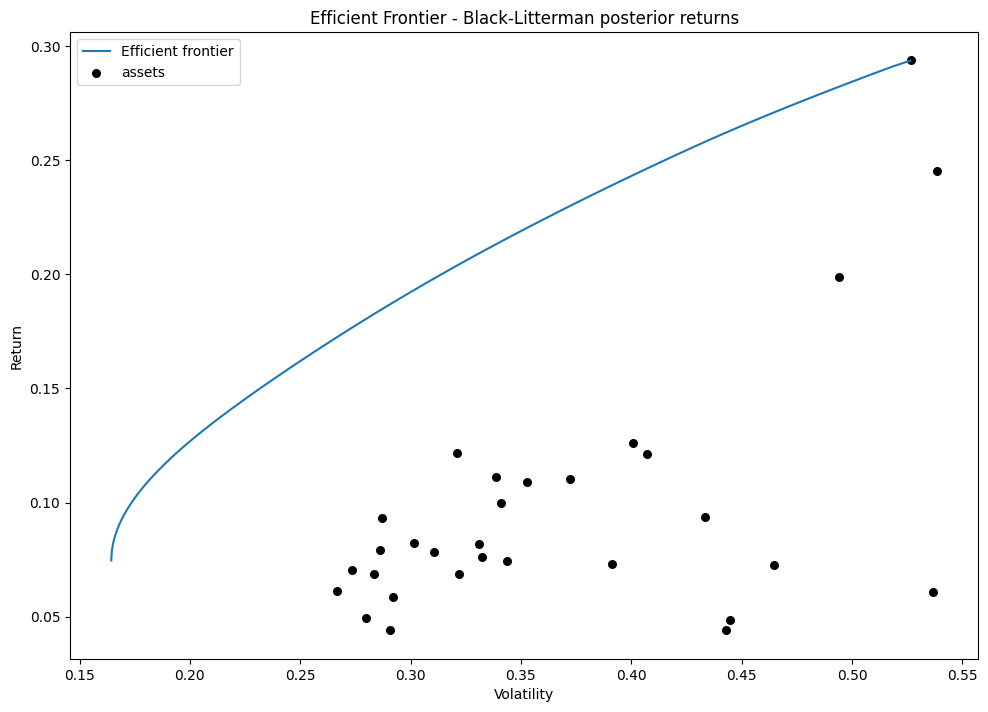

In [25]:
# Draw Efficient frontier
fig, ax = plt.subplots(figsize=(10, 7))
ef_plot = EfficientFrontier(bl_returns, bl_cov)
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True)
ax.set_title('Efficient Frontier - Black-Litterman posterior returns')
plt.show()

In [26]:
comparison_all.to_csv('../data/processed/week3_allocation_weights.csv')